In [ ]:
import pandas as pd

df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.shape
df.head()
df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Dataset Overview

- The dataset contains 7043 customer records and 21 columns.
- Most variables are categorical (`object` type).
- Numerical features include:
  - tenure
  - MonthlyCharges
  - SeniorCitizen
- No official missing values are detected.
- However, `TotalCharges` is stored as an object instead of a numeric type,
  suggesting hidden invalid or missing values.

In [ ]:
df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


# `TotalCharges` Case

- We can see that there is 11 missing values disguised as empty spaces in `TotalCharges` column

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


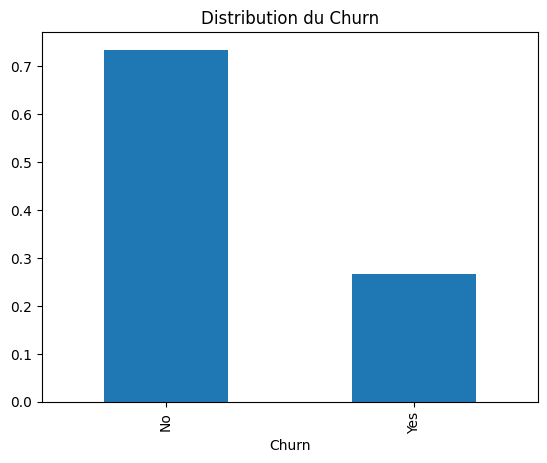

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

churn_distribution = df['Churn'].value_counts(normalize=True)

print(churn_distribution)

churn_distribution.plot(kind='bar')

plt.title('Distribution du Churn')
plt.show()

The dataset is imbalanced (73% No Churn vs 27% Churn). This imbalance may lead to misleading accuracy scores, as the model could tend to favor the majority class.

array([[<Axes: title={'center': 'tenure'}>,
        <Axes: title={'center': 'MonthlyCharges'}>],
       [<Axes: title={'center': 'TotalCharges'}>, <Axes: >]], dtype=object)

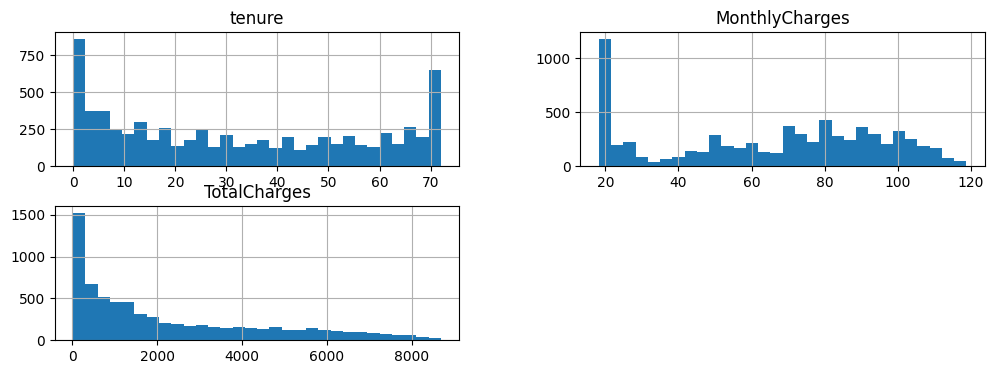

In [ ]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols].hist(bins=30, figsize=(12, 4))

## Numerical Features Insights

- `tenure` shows two major groups of customers:
  many customers are either new customers or long-term customers.

- `MonthlyCharges` has a concentration at lower values
  (likely corresponding to cheaper subscriptions),
  while the rest of the distribution is more spread out.

- `TotalCharges` is heavily right-skewed:
  most customers have relatively low total charges,
  and the number of customers decreases as total charges increase.

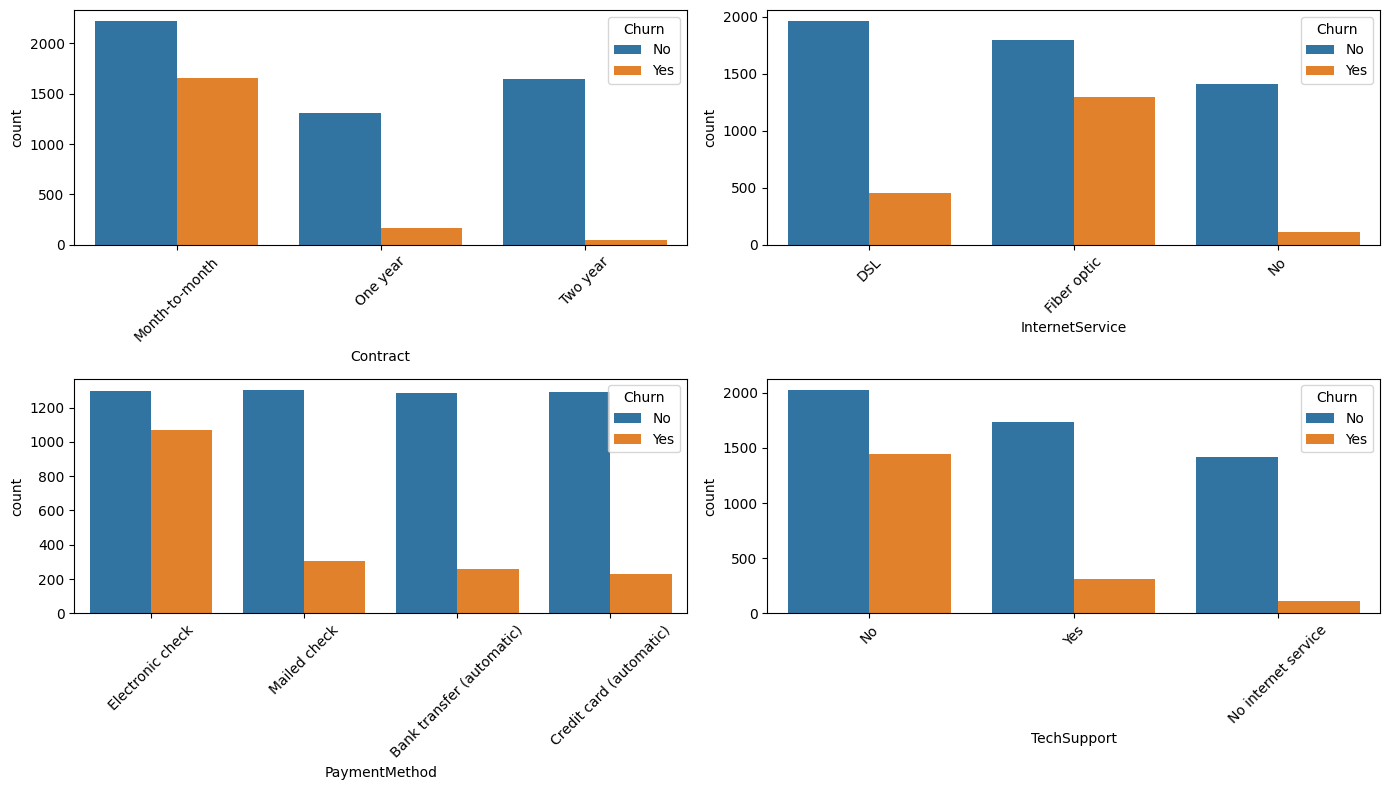

In [16]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=ax)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

## Categorical Features vs Churn

- Customers with month-to-month contracts show significantly higher churn rates.
- Fiber optic users tend to churn more compared to other internet services.
- Customers using electronic check as payment method are more likely to churn.
- Having technical support is associated with lower churn rates.

## Key Insights

- Dataset: 7043 clients, 21 features
- Class imbalance: 73% No Churn / 27% Churn → need to fix that in preprocessing
- TotalCharges contains missing values ​​disguised as empty spaces
- Clients with monthly contracts churn much more than those with annual contracts
- Tenure is strongly correlated with churn: new clients churn more
- High MonthlyCharges = higher churn rate